In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r'../data/wnba_players_data.csv')
data.drop(columns=['Unnamed: 0'], inplace=True)
data.head()

,Season,Player,G,MP,GS,FG,FGA,FG%,3P,3PA,...,USG%,ORtg,DRtg,OWS,DWS,WS,WS/40,PLUS_MINUS,award_share,is_mvp
0,1997,Anita Maxwell,9,63,0,8,25,0.320,0,0,...,25.6,72.0,89.0,-0.2,0.1,-0.1,-0.036,-5,0.0,0
1,1997,Tammi Reiss,28,831,26,72,231,0.312,30,101,...,17.0,87.0,105.0,0.2,-0.7,-0.5,-0.024,-288,0.0,0
2,1997,Catarina Pollini,13,94,0,8,22,0.364,0,0,...,17.6,77.0,92.0,-0.1,0.1,0.0,0.005,19,0.0,0
3,1997,Bridget Pettis,28,842,28,107,320,0.334,41,134,...,24.0,94.0,88.0,1.5,1.7,3.2,0.151,91,0.0,0
4,1997,Kim Perrot,28,692,24,59,162,0.364,28,99,...,16.5,87.0,87.0,0.2,1.5,1.7,0.098,155,0.0,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4691 entries, 0 to 4690
Data columns (total 46 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Season       4691 non-null   int64  
 1   Player       4691 non-null   str    
 2   G            4691 non-null   int64  
 3   MP           4691 non-null   int64  
 4   GS           4691 non-null   int64  
 5   FG           4691 non-null   int64  
 6   FGA          4691 non-null   int64  
 7   FG%          4691 non-null   float64
 8   3P           4691 non-null   int64  
 9   3PA          4691 non-null   int64  
 10  3P%          4691 non-null   float64
 11  2P           4691 non-null   int64  
 12  2PA          4691 non-null   int64  
 13  2P%          4691 non-null   float64
 14  FT           4691 non-null   int64  
 15  FTA          4691 non-null   int64  
 16  FT%          4691 non-null   float64
 17  ORB          4691 non-null   int64  
 18  TRB          4691 non-null   int64  
 19  AST          4691

In [4]:
data.isna().sum()

Season         0
Player         0
G              0
MP             0
GS             0
FG             0
FGA            0
FG%            0
3P             0
3PA            0
3P%            0
2P             0
2PA            0
2P%            0
FT             0
FTA            0
FT%            0
ORB            0
TRB            0
AST            0
STL            0
BLK            0
TOV            0
PF             0
PTS            0
PER            0
TS%            0
eFG%           0
3PAr           0
FTr            0
ORB%           0
TRB%           0
AST%           0
STL%           0
BLK%           0
TOV%           0
USG%           0
ORtg           0
DRtg           0
OWS            0
DWS            0
WS             0
WS/40          0
PLUS_MINUS     0
award_share    0
is_mvp         0
dtype: int64

In [5]:
data.columns

Index(['Season', 'Player', 'G', 'MP', 'GS', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PER', 'TS%', 'eFG%', '3PAr', 'FTr',
       'ORB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'ORtg', 'DRtg',
       'OWS', 'DWS', 'WS', 'WS/40', 'PLUS_MINUS', 'award_share', 'is_mvp'],
      dtype='str')

In [6]:
df = pd.DataFrame()
# subset important features
# features that show players skill level as well as their impact on the court
df = data[['Season', 'Player', 'TS%','WS', 'PER', 'USG%','PLUS_MINUS','award_share','is_mvp']]
df['pts_per_game'] = data['PTS'] / data['G']
df['stl_per_game'] = data['STL'] / data['G']
df['ast_per_game'] = data['AST'] / data['G']
df['trb_per_game'] = data['TRB'] / data['G']
df['blk_per_game'] = data['BLK'] / data['G']

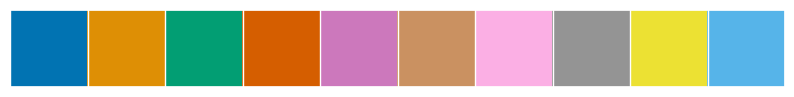

In [14]:
sns.set_style('darkgrid')
sns.set_palette('colorblind')
sns.set(font_scale=0.8)

palette = sns.color_palette('colorblind')
sns.palplot(palette)

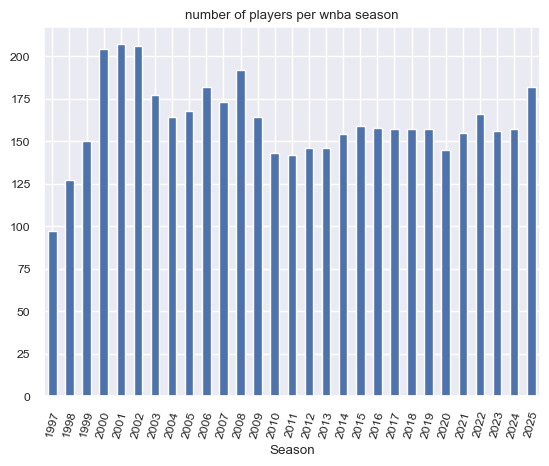

In [15]:
df['Season'].value_counts(sort=False).plot.bar()
plt.title("number of players per wnba season")
plt.xticks(rotation=75)
plt.show()

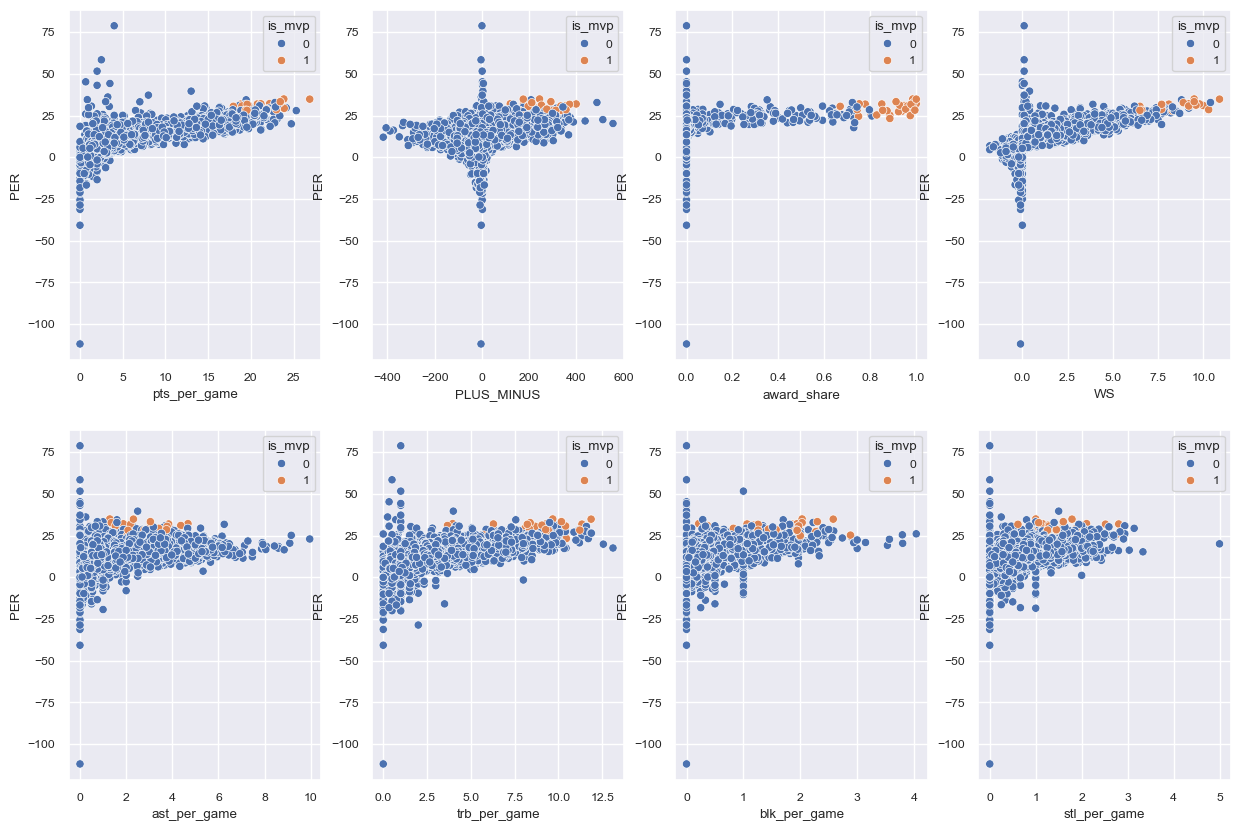

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='pts_per_game',
    y='PER',
    ax=axes[0,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='PLUS_MINUS',
    y='PER',
    ax=axes[0,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='PER',
    x='award_share',
    ax=axes[0,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='WS',
    y='PER',
    ax=axes[0,3]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='PER',
    x='ast_per_game',
    ax=axes[1,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='PER',
    x='trb_per_game',
    ax=axes[1,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='PER',
    x='blk_per_game',
    ax=axes[1,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='PER',
    x='stl_per_game',
    ax=axes[1,3]
)

plt.show()

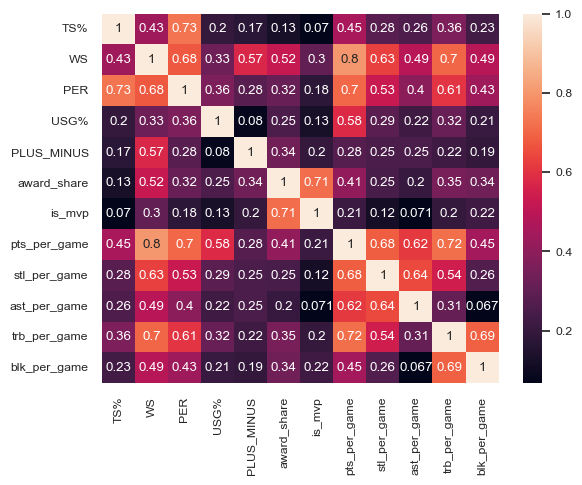

In [17]:
sns.heatmap(data=df[df.columns[2:]].corr(), annot=True)
plt.show()

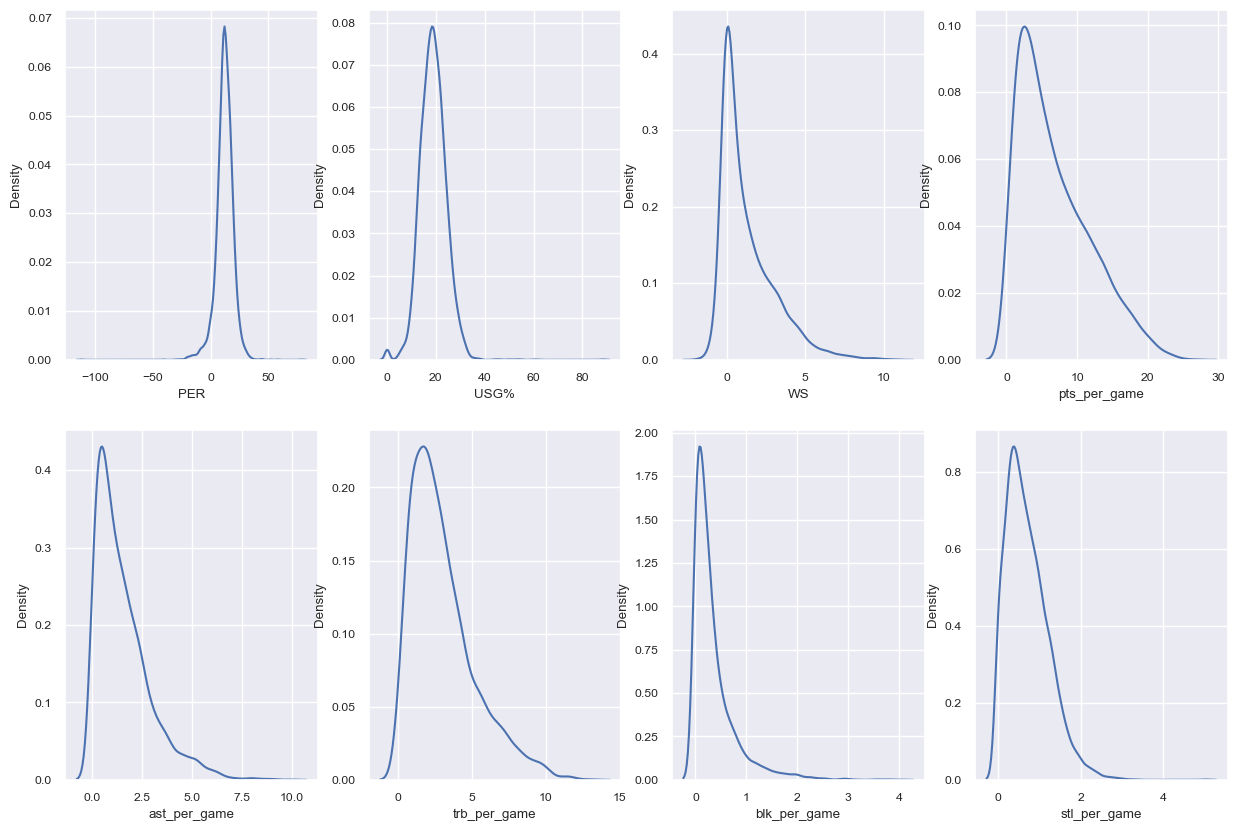

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.kdeplot(
    data=df,
    x='PER',
    ax=axes[0,0]
)
sns.kdeplot(
    data=df,
    x='USG%',
    ax=axes[0,1]
)
sns.kdeplot(
    data=df,
    x='WS',
    ax=axes[0,2]
)
sns.kdeplot(
    data=df,
    x='pts_per_game',
    ax=axes[0,3]
)
sns.kdeplot(
    data=df,
    x='ast_per_game',
    ax=axes[1,0]
)
sns.kdeplot(
    data=df,
    x='trb_per_game',
    ax=axes[1,1]
)
sns.kdeplot(
    data=df,
    x='blk_per_game',
    ax=axes[1,2]
)
sns.kdeplot(
    data=df,
    x='stl_per_game',
    ax=axes[1,3]
)

plt.show()

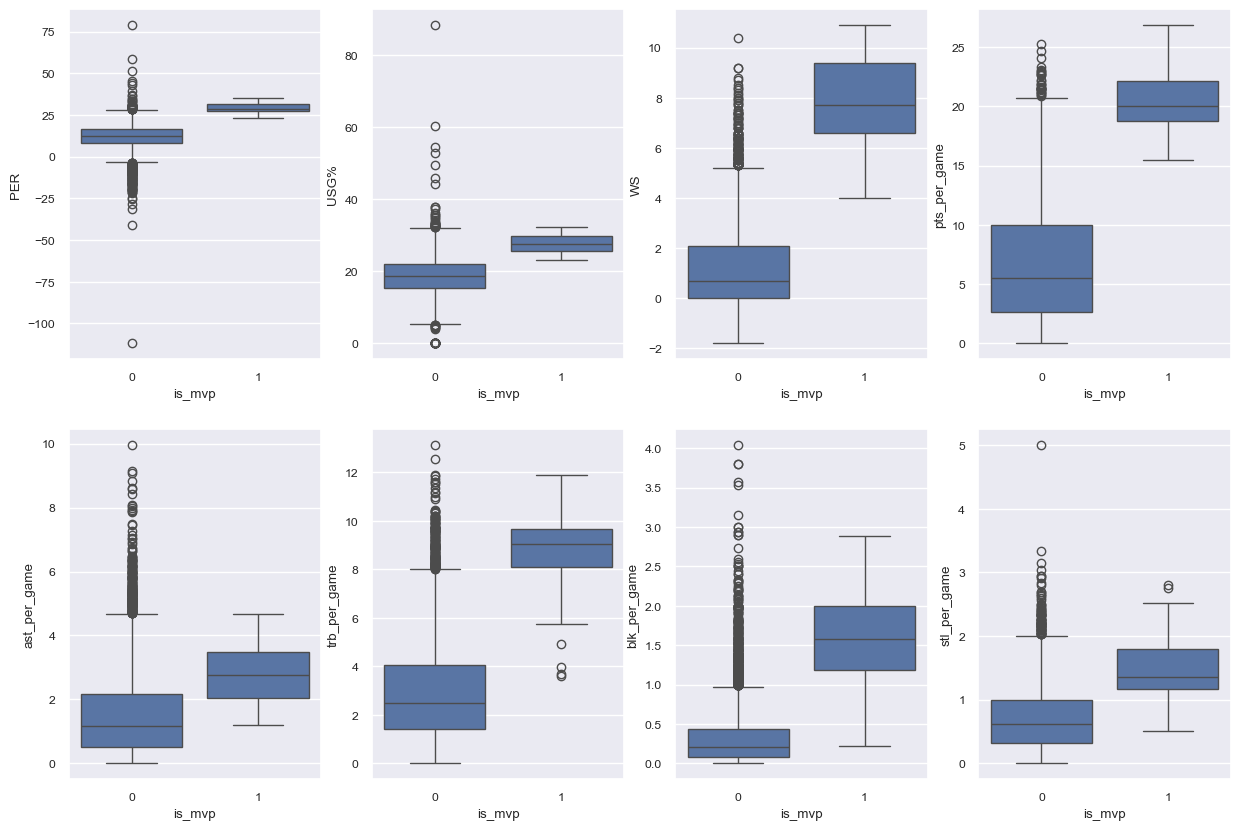

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.boxplot(
    data=df,
    x='is_mvp',
    y='PER',
    ax=axes[0,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='USG%',
    ax=axes[0,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='WS',
    ax=axes[0,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='pts_per_game',
    ax=axes[0,3]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='ast_per_game',
    ax=axes[1,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='trb_per_game',
    ax=axes[1,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='blk_per_game',
    ax=axes[1,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='stl_per_game',
    ax=axes[1,3]
)

plt.show()

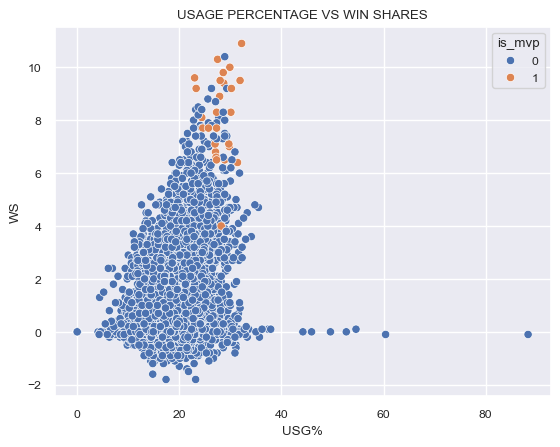

In [ ]:
sns.scatterplot(data=data, x='USG%', y='WS', hue='is_mvp')
plt.title("USAGE PERCENTAGE VS WIN SHARES")
plt.show()